In [2]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.4 MB/s eta 0:00:00


Explained variance ratio: [0.11300849 0.08838171]
Cumulative: [0.11300849 0.2013902 ]


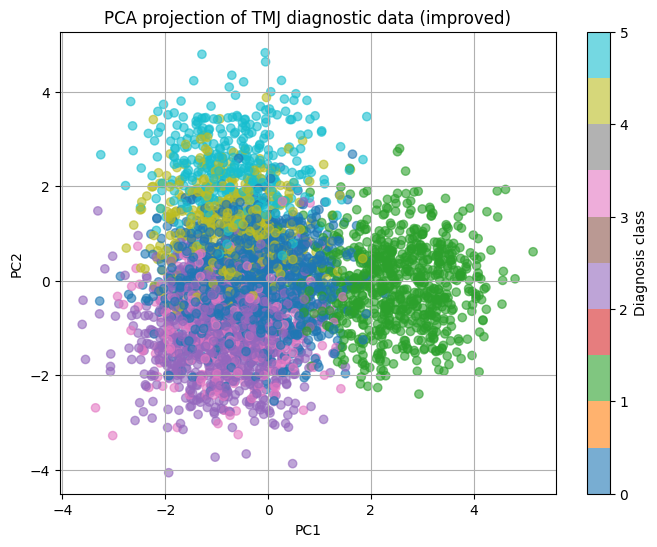

Accuracy: 0.895
Macro F1: 0.904
ROC-AUC (macro): 0.989
    feature  importance
0    feat_0   10.024313
3    feat_3    7.417229
8    feat_8    7.001840
16  feat_16    6.430346
9    feat_9    6.317502
4    feat_4    6.190377
1    feat_1    6.115804
12  feat_12    6.030275
15  feat_15    5.957937
13  feat_13    5.957483


In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt

np.random.seed(42)
n_samples = 4000
n_features = 20  # увеличил число признаков

# Диагнозы: 0-норма,1-мышечная,2-артроз,3-артрит,4-вывих,5-анкилоз
diagnosis = np.random.choice([0,1,2,3,4,5], size=n_samples, p=[0.3,0.2,0.2,0.1,0.1,0.1])

# Генерация базовых случайных признаков
X = np.random.randn(n_samples, n_features)

for i in range(n_samples):
    if diagnosis[i] == 0:  # норма
        X[i, 0:3] += 0.0   # без изменений
    elif diagnosis[i] == 1:  # мышечная дисфункция
        X[i, 3:6] += 1.8    # асимметрия ЭМГ
        X[i, 6:8] += 1.2
    elif diagnosis[i] == 2:  # артроз
        X[i, 0] += 2.0       # ширина суставной щели
        X[i, 1] += 1.5       # остеофиты
        X[i, 2] += 1.2
    elif diagnosis[i] == 3:  # артрит
        X[i, 0] += 1.0
        X[i, 8:10] += 2.0    # воспалительные признаки
        X[i, 11] += 1.5
    elif diagnosis[i] == 4:  # вывих диска
        X[i, 12:14] += 2.2   # смещение
        X[i, 14] += 1.8
    elif diagnosis[i] == 5:  # анкилоз
        X[i, 15:17] += 2.5   # ограничение подвижности
        X[i, 17] += 2.0

X_df = pd.DataFrame(X, columns=[f'feat_{i}' for i in range(n_features)])
y = diagnosis

# Предобработка
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_df)

# PCA для визуализации
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Cumulative:", pca.explained_variance_ratio_.cumsum())

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='tab10', alpha=0.6)
plt.colorbar(scatter, label='Diagnosis class')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA projection of TMJ diagnostic data (improved)')
plt.grid(True)
plt.show()

# Обучение классификатора
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42)
model = CatBoostClassifier(iterations=300, depth=7, learning_rate=0.1, verbose=False, random_seed=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')
roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovo', average='macro')

print(f"Accuracy: {acc:.3f}")
print(f"Macro F1: {f1:.3f}")
print(f"ROC-AUC (macro): {roc_auc:.3f}")

feat_importance = pd.DataFrame({'feature': X_df.columns, 'importance': model.feature_importances_})
print(feat_importance.sort_values('importance', ascending=False).head(10))